In [ ]:
# Удаление пропущенных значений
df = df.dropna(subset=['ds', 'y'])
df = df.sort_values('ds').reset_index(drop=True)

data_train.tail(-5) и head

In [ ]:
print(model.summary())

In [ ]:
print(model.params()) ????

!!!!TBATS нет экзогенных факторов 

TBATS модели разработаны De Livera, Hyndman, Snyder (2011). Данный подход использует комбинацию из рядов Фурье, модель пространства состояний с экспоненциальным сглаживанием, а также преобразование Бокса-Кокса. Причем выбор параметров осуществляется полностью автоматизированным образом.

Тесты Дики-Фуллера (ADF) и KPSS
Полагаться только на визуальный анализ рискованно — иногда тренд или сезонность могут быть не так очевидны. Чтобы принять объективное решение, используют статистические тесты. Самый популярный из них — расширенный тест Дики-Фуллера (Augmented Dickey-Fuller Test, ADF). 

from statsmodels.tsa.stattools import adfuller
# Проводим ADF-тест
result_adf = adfuller(df['Passengers'])
# Выводим результат
print('ADF Statistic:', result_adf[0])
print('p-value:', result_adf[1])

Результат выполнения кода:
ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641
Наш p-value равен 0.99. Это значительно больше порогового значения 0.05.
Вывод: Тест ADF с уверенностью говорит нам: "Ребята, у вас нет никаких оснований считать этот ряд стационарным". Наша визуальная догадка полностью подтвердилась.

In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree
import math #### все функции
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve
from IPython.display import display, HTML
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier

from sympy import *

import mpl_toolkits.mplot3d as p3
import random
import time


from functools import partial
#from ipywidgets import interact, RadioButtons, IntSlider, FloatSlider, Dropdown, BoundedFloatText
from numpy.linalg import norm

from scipy import sparse

random.seed(42) # начальное состояние генератора случайных чисел, чтобы можно было воспроизводить результаты.

#!unzip «путь_до_архива»
#Всё извлечётся в память Colab.

In [27]:
# plotting
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns

# не ЕTNA модели Prophet, TBATS, SARIMAX — модели для предсказания временных рядов
import statsmodels

# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# models
from tbats import TBATS
from prophet import Prophet
from pmdarima import auto_arima

# make plots bigger
from pylab import rcParams
rcParams['figure.figsize'] = 15, 7

In [28]:
import plotly.express as px
import statsmodels.api as sm


In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL

In [30]:
# metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# models
from tbats import TBATS
from prophet import Prophet
from pmdarima import auto_arima

In [31]:
import warnings
warnings.filterwarnings('ignore')

In [46]:
df2 = pd.read_csv(
    '/workspaces/pyt_begin/data_data/a10.csv'
    )

In [47]:
data= df2

In [8]:
# Дату уставнавливаем как индекс
data = data.set_index('date')

# Выделяем данные о продажах
data = data['value']

TypeError: unhashable type: 'numpy.ndarray'

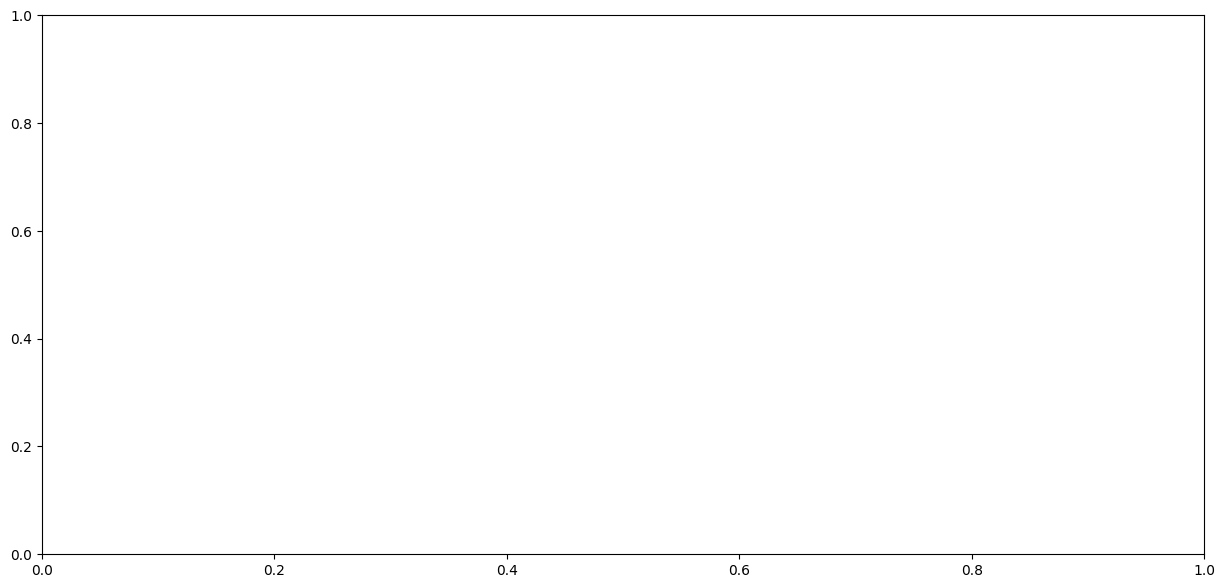

In [48]:
plt.plot(data)

In [49]:
test_size = 12
data_train = data.iloc[: -test_size]
data_test  = data.iloc[-test_size:]

In [50]:
data_test,

(           date      value
 192  2007-07-01  21.834890
 193  2007-08-01  23.930204
 194  2007-09-01  22.930357
 195  2007-10-01  23.263340
 196  2007-11-01  25.250030
 197  2007-12-01  25.806090
 198  2008-01-01  29.665356
 199  2008-02-01  21.654285
 200  2008-03-01  18.264945
 201  2008-04-01  23.107677
 202  2008-05-01  22.912510
 203  2008-06-01  19.431740,)

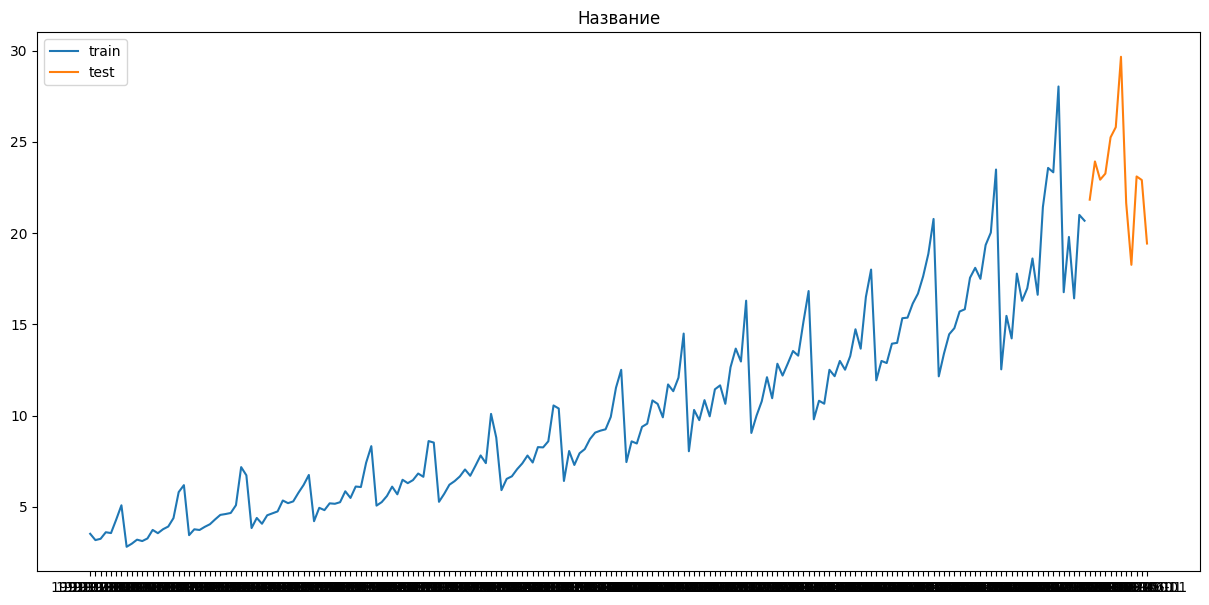

In [33]:
plt.title('Название')
plt.plot(data_train, label='train')
plt.plot(data_test, label='test')
plt.legend();

In [12]:
compare_table = None


def add_results_in_comparison_table(method: str, y_true, y_forecast) -> pd.DataFrame:
    """
    Добавляет новую строчку в таблицу compare_table с результатами текущей модели.
    Если ранее модель была уже добавлена в таблицу, то старая строчка перезапишется на новую.
    
    Параметры:
    - method: имя модели
    - y_true: истинные значения
    - y_forecast: предсказанные значения.
    """
    
    # Обращаемся к глобальной переменной
    global compare_table
    
    # Считаем метрики
    result_row = {
        'method': method,
        "MSE": mean_squared_error(y_true=y_true, y_pred=y_forecast),
        "MAE": mean_absolute_error(y_true=y_true, y_pred=y_forecast),
        "MAPE": mean_absolute_percentage_error(y_true=y_true, y_pred=y_forecast)
    }
    
    # Записываем результат в таблицу
    if compare_table is None:
        compare_table = pd.DataFrame([result_row])
    else:
        if method in list(compare_table['method']):
            compare_table = compare_table[compare_table['method'] != method]

        compare_table = pd.concat([compare_table, pd.DataFrame([result_row])])
        compare_table.index = np.arange(len(compare_table))
    return compare_table


def mean_absolute_percentage_error(y_true, y_pred) -> float: 
    """Считает MAPE для y_true и y_pred"""
    
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [51]:
tbats_estimator = TBATS(n_jobs=2)
model = tbats_estimator.fit(data_train)

InputArgsException: y series is invalid

In [45]:
data_train,

(date
 1991-07-01     3.526591
 1991-08-01     3.180891
 1991-09-01     3.252221
 1991-10-01     3.611003
 1991-11-01     3.565869
                 ...    
 2007-02-01    16.763869
 2007-03-01    19.792754
 2007-04-01    16.427305
 2007-05-01    21.000742
 2007-06-01    20.681002
 Name: value, Length: 192, dtype: float64,)

In [ ]:
print(model.summary())

In [ ]:
tbats_forecast, confidence_info = model.forecast(steps=365, confidence_level=0.95)

In [ ]:
plot_results(data_train, data_test, tbats_forecast, plot_conf_int=True, 
             left_bound=confidence_info['lower_bound'], 
             right_bound=confidence_info['upper_bound'])

In [ ]:
final_table = add_results_in_comparison_table('TBATS model', data_test, tbats_forecast)

check_predictive_interval(data_test, 
                          left_bound=confidence_info['lower_bound'],
                          right_bound=confidence_info['upper_bound'])

    method	                MSE	        MAE	        MAPE
0	Prophet	            24.680305	4.032057	22.233153
1	Prophet + holidays	24.949507	4.061328	22.420432
2	Prophet + boxcox	24.172479	3.992453	21.729038
3	Auto arima model	70.907815	6.650232	28.894886
4	Auto arima model wirh Fourier exog	70.907815	6.650232	28.894886
5	TBATS model	        23.637445	3.857729	19.791148